# E3 – Temperaturowa zależność oporu przewodników

Pomiar oporu trzech materiałów (Pt, Ni, C-grafit) w układzie mostka Wheatstone'a.  
Ponieważ R₁ = R₂ = 10,5 Ω, opór badanego opornika równa się odczytowi na opornicy dekadowej: **R_X = R_D**.  
Model liniowy: R(T) = R₀ + R₀ · α · (T − T₀), gdzie T₀ = 20 °C.  
Współczynnik temperaturowy wyznaczany z regresji liniowej: **α = a / R₀**, gdzie *a* to nachylenie prostej.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

# Paleta kolorów z Astorii
COLORS    = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
C_DATA    = '#37474F'   # punkty pomiarowe w wykresach regresji
C_FIT     = '#e53935'   # prosta regresji

# Pt → COLORS[0], Ni → COLORS[1], C-grafit → COLORS[2]
MAT_COLOR = {'Pt': COLORS[0], 'Ni': COLORS[1], 'C': COLORS[2]}


def format_val_unc(val, unc, n=2):
    """Formatuje wartość ± niepewność z zaokrągleniem do n cyfr znaczących niepewności."""
    if not np.isfinite(unc) or not np.isfinite(val) or unc == 0:
        return f"{val:.4g}", f"{unc:.4g}"
    d = int(np.floor(np.log10(abs(unc)))) - (n - 1)
    unc_r = round(unc, -d)
    val_r = round(val, -d)
    if d <= 0:
        fmt = f".{-d}f"
        return f"{val_r:{fmt}}", f"{unc_r:{fmt}}"
    else:
        return f"{val_r:.0f}", f"{unc_r:.0f}"

## 1. Wczytanie danych

In [10]:
# Stałe układu pomiarowego
R1 = 10.5   # Ω
R2 = 10.5   # Ω  → R_X = (R1/R2) * R_D = R_D
T0 = 22.0   # °C – temperatura odniesienia

# Wartości tablicowe współczynników temperaturowych [1/K]
alpha_lit = {'Pt': 0.0039, 'Ni': 0.006, 'C': -0.0005}

materials = {
    'Pt': {'label': 'Platyna (Pt)', 'heating_file': 'pt_heating.csv', 'cooling_file': 'pt_cooling.csv'},
    'Ni': {'label': 'Nikiel (Ni)', 'heating_file': 'ni_heating.csv', 'cooling_file': 'ni_cooling.csv'},
    'C':  {'label': 'Grafit (C)',  'heating_file': 'c_heating.csv',  'cooling_file': 'c_cooling.csv'},
}
mat_list = list(materials.keys())   # ['Pt', 'Ni', 'C']

data = {}
for mat, info in materials.items():
    dh = pd.read_csv(info['heating_file'])
    dc = pd.read_csv(info['cooling_file'])
    data[mat] = {'heating': dh, 'cooling': dc}
    print(f"{info['label']}: ogrzewanie {len(dh)} pkt, chłodzenie {len(dc)} pkt")

Platyna (Pt): ogrzewanie 25 pkt, chłodzenie 22 pkt
Nikiel (Ni): ogrzewanie 25 pkt, chłodzenie 22 pkt
Grafit (C): ogrzewanie 26 pkt, chłodzenie 22 pkt


## 2. Wykresy surowych danych z niepewnościami

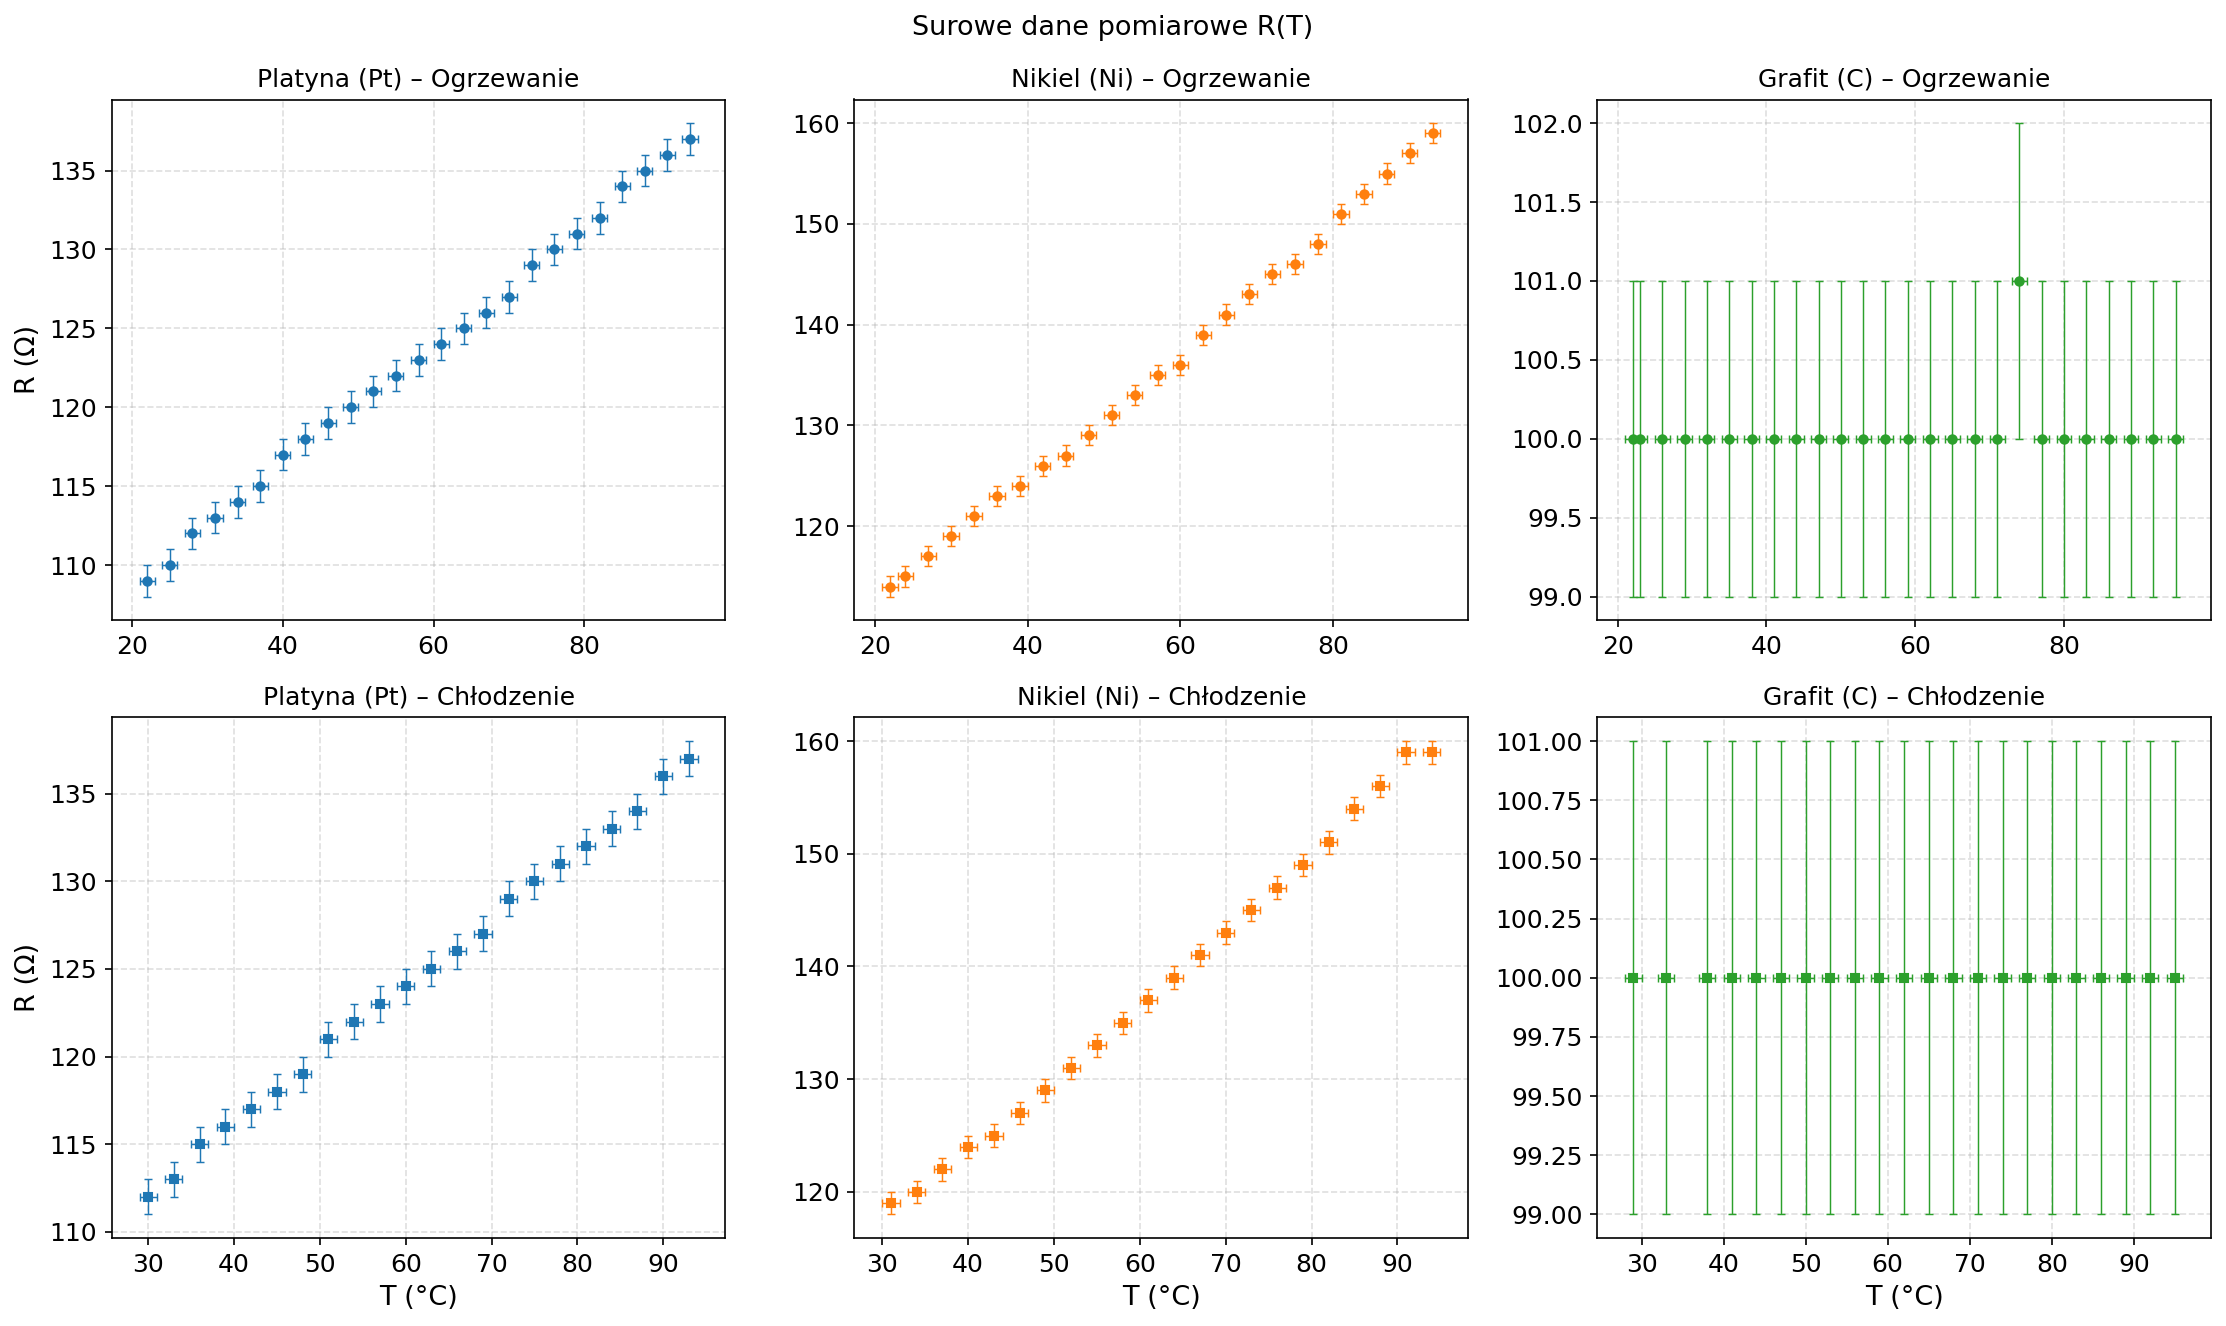

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, mat in enumerate(mat_list):
    dh = data[mat]['heating']
    dc = data[mat]['cooling']
    c  = MAT_COLOR[mat]

    for row, (df, phase_label, marker) in enumerate([
        (dh, 'Ogrzewanie', 'o'),
        (dc, 'Chłodzenie', 's'),
    ]):
        ax = axes[row, col]
        ax.errorbar(
            df['T'], df['R'], xerr=df['u_T'], yerr=df['u_R'],
            fmt=marker, color=c, markersize=4, capsize=2,
            elinewidth=0.7, capthick=0.7,
        )
        ax.set_title(f"{materials[mat]['label']} – {phase_label}", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.4)
        if row == 1:
            ax.set_xlabel('T (°C)')
        if col == 0:
            ax.set_ylabel('R (Ω)')

fig.suptitle("Surowe dane pomiarowe R(T)", fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig('wykres1_surowe_dane.pdf', format='pdf', bbox_inches='tight')
plt.close(fig)

## 3. Regresja liniowa R(τ) = a·τ + b, gdzie τ = T − T₀

Zgodnie z modelem fizycznym $R(T) = R_0[1 + \alpha(T-T_0)]$, regresję prowadzi się względem **temperatury zredukowanej** $\tau = T - T_0$:

$$R(\tau) = \underbrace{R_0\,\alpha}_{a}\;\tau + \underbrace{R_0}_{b}$$

Dzięki temu wyraz wolny $b$ **bezpośrednio równa się $R_0$** i można go porównać z pomiarem bezpośrednim na mostku. Współczynnik temperaturowy to $\alpha = a/b$.

Używamy ważonej metody najmniejszych kwadratów (`scipy.curve_fit`, `absolute_sigma=True`).

**Pasmo niepewności regresji** w punkcie $\tau$:
$$u_{\hat{R}}(\tau) = \sqrt{\sigma_a^2\,\tau^2 + \sigma_b^2 + 2\tau\,\mathrm{cov}(a,b)}$$
W szczególności w punkcie $\tau=0$ (czyli $T=T_0$): $u_{\hat{R}}(0) = \sigma_b = u(R_0)$.

**Wyznaczenie $\alpha$ z propagacją niepewności** (z uwzględnieniem korelacji $a$ i $b$):
$$u(\alpha) = \sqrt{\frac{\sigma_a^2}{b^2} + \frac{a^2\,\sigma_b^2}{b^4} - \frac{2a\,\mathrm{cov}(a,b)}{b^3}}$$

In [12]:
def linear_model(tau, a, b):
    return a * tau + b


def fit_phase(mat, phase):
    """Dopasowanie R vs τ = T − T₀. Wyraz wolny b = R₀ bezpośrednio."""
    if phase == 'combined':
        dh = data[mat]['heating']
        dc = data[mat]['cooling']
        T_arr   = np.concatenate([dh['T'].values,   dc['T'].values],   dtype=float)
        R_arr   = np.concatenate([dh['R'].values,   dc['R'].values],   dtype=float)
        u_R_arr = np.concatenate([dh['u_R'].values, dc['u_R'].values], dtype=float)
    else:
        df      = data[mat][phase]
        T_arr   = df['T'].values.astype(float)
        R_arr   = df['R'].values.astype(float)
        u_R_arr = df['u_R'].values.astype(float)

    tau_arr = T_arr - T0  # temperatura zredukowana

    popt, pcov = curve_fit(linear_model, tau_arr, R_arr,
                           sigma=u_R_arr, absolute_sigma=True)
    a, b   = popt
    sa     = np.sqrt(pcov[0, 0])
    sb     = np.sqrt(pcov[1, 1])
    cov_ab = pcov[0, 1]

    # b = R₀ bezpośrednio z regresji
    R0   = b
    u_R0 = sb

    # α = a/b, propagacja z korelacją (∂α/∂a = 1/b, ∂α/∂b = −a/b²)
    alpha   = a / b
    u_alpha = np.sqrt(sa**2 / b**2
                      + (a * sb)**2 / b**4
                      - 2 * a * cov_ab / b**3)

    w      = 1.0 / u_R_arr**2
    SS_res = np.sum(w * (R_arr - linear_model(tau_arr, *popt))**2)
    SS_tot = np.sum(w * (R_arr - np.average(R_arr, weights=w))**2)
    r2     = 1.0 - SS_res / SS_tot

    return dict(a=a, b=b, sa=sa, sb=sb, cov_ab=cov_ab, pcov=pcov,
                R0=R0, u_R0=u_R0, alpha=alpha, u_alpha=u_alpha,
                T_all=T_arr, tau_all=tau_arr, R_all=R_arr, u_R_all=u_R_arr, r2=r2)


# Trzy zestawy wyników
results_h   = {mat: fit_phase(mat, 'heating')  for mat in mat_list}
results_c   = {mat: fit_phase(mat, 'cooling')  for mat in mat_list}
results_all = {mat: fit_phase(mat, 'combined') for mat in mat_list}
results = results_all

for phase_label, res_dict in [('Ogrzewanie', results_h),
                               ('Chłodzenie', results_c),
                               ('Łączone',    results_all)]:
    print(f"\n{'─'*75}")
    print(f"  {phase_label}")
    print(f"{'─'*75}")
    for mat in mat_list:
        r = res_dict[mat]
        print(f"  {materials[mat]['label']:15s}  "
              f"a=({r['a']:.4f}±{r['sa']:.4f}) Ω/°C  "
              f"b=R₀=({r['b']:.2f}±{r['sb']:.2f}) Ω  "
              f"R²={r['r2']:.5f}")


───────────────────────────────────────────────────────────────────────────
  Ogrzewanie
───────────────────────────────────────────────────────────────────────────
  Platyna (Pt)     a=(0.3821±0.0092) Ω/°C  b=R₀=(109.41±0.39) Ω  R²=0.99790
  Nikiel (Ni)      a=(0.6299±0.0093) Ω/°C  b=R₀=(113.41±0.38) Ω  R²=0.99792
  Grafit (C)       a=(0.0013±0.0088) Ω/°C  b=R₀=(99.99±0.37) Ω  R²=0.02155

───────────────────────────────────────────────────────────────────────────
  Chłodzenie
───────────────────────────────────────────────────────────────────────────
  Platyna (Pt)     a=(0.3892±0.0112) Ω/°C  b=R₀=(109.17±0.49) Ω  R²=0.99830
  Nikiel (Ni)      a=(0.6623±0.0112) Ω/°C  b=R₀=(111.58±0.50) Ω  R²=0.99738
  Grafit (C)       a=(-0.0000±inf) Ω/°C  b=R₀=(100.00±inf) Ω  R²=-inf

───────────────────────────────────────────────────────────────────────────
  Łączone
───────────────────────────────────────────────────────────────────────────
  Platyna (Pt)     a=(0.3850±0.0071) Ω/°C  b=R₀=(109.32±

/var/folders/rf/r1ckh7bd7hjfcr3c3b8j80840000gn/T/ipykernel_20718/3410976498.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear_model, tau_arr, R_arr,
/var/folders/rf/r1ckh7bd7hjfcr3c3b8j80840000gn/T/ipykernel_20718/3410976498.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  r2     = 1.0 - SS_res / SS_tot


## 4. Wykresy z regresjami liniowymi i pasmem niepewności

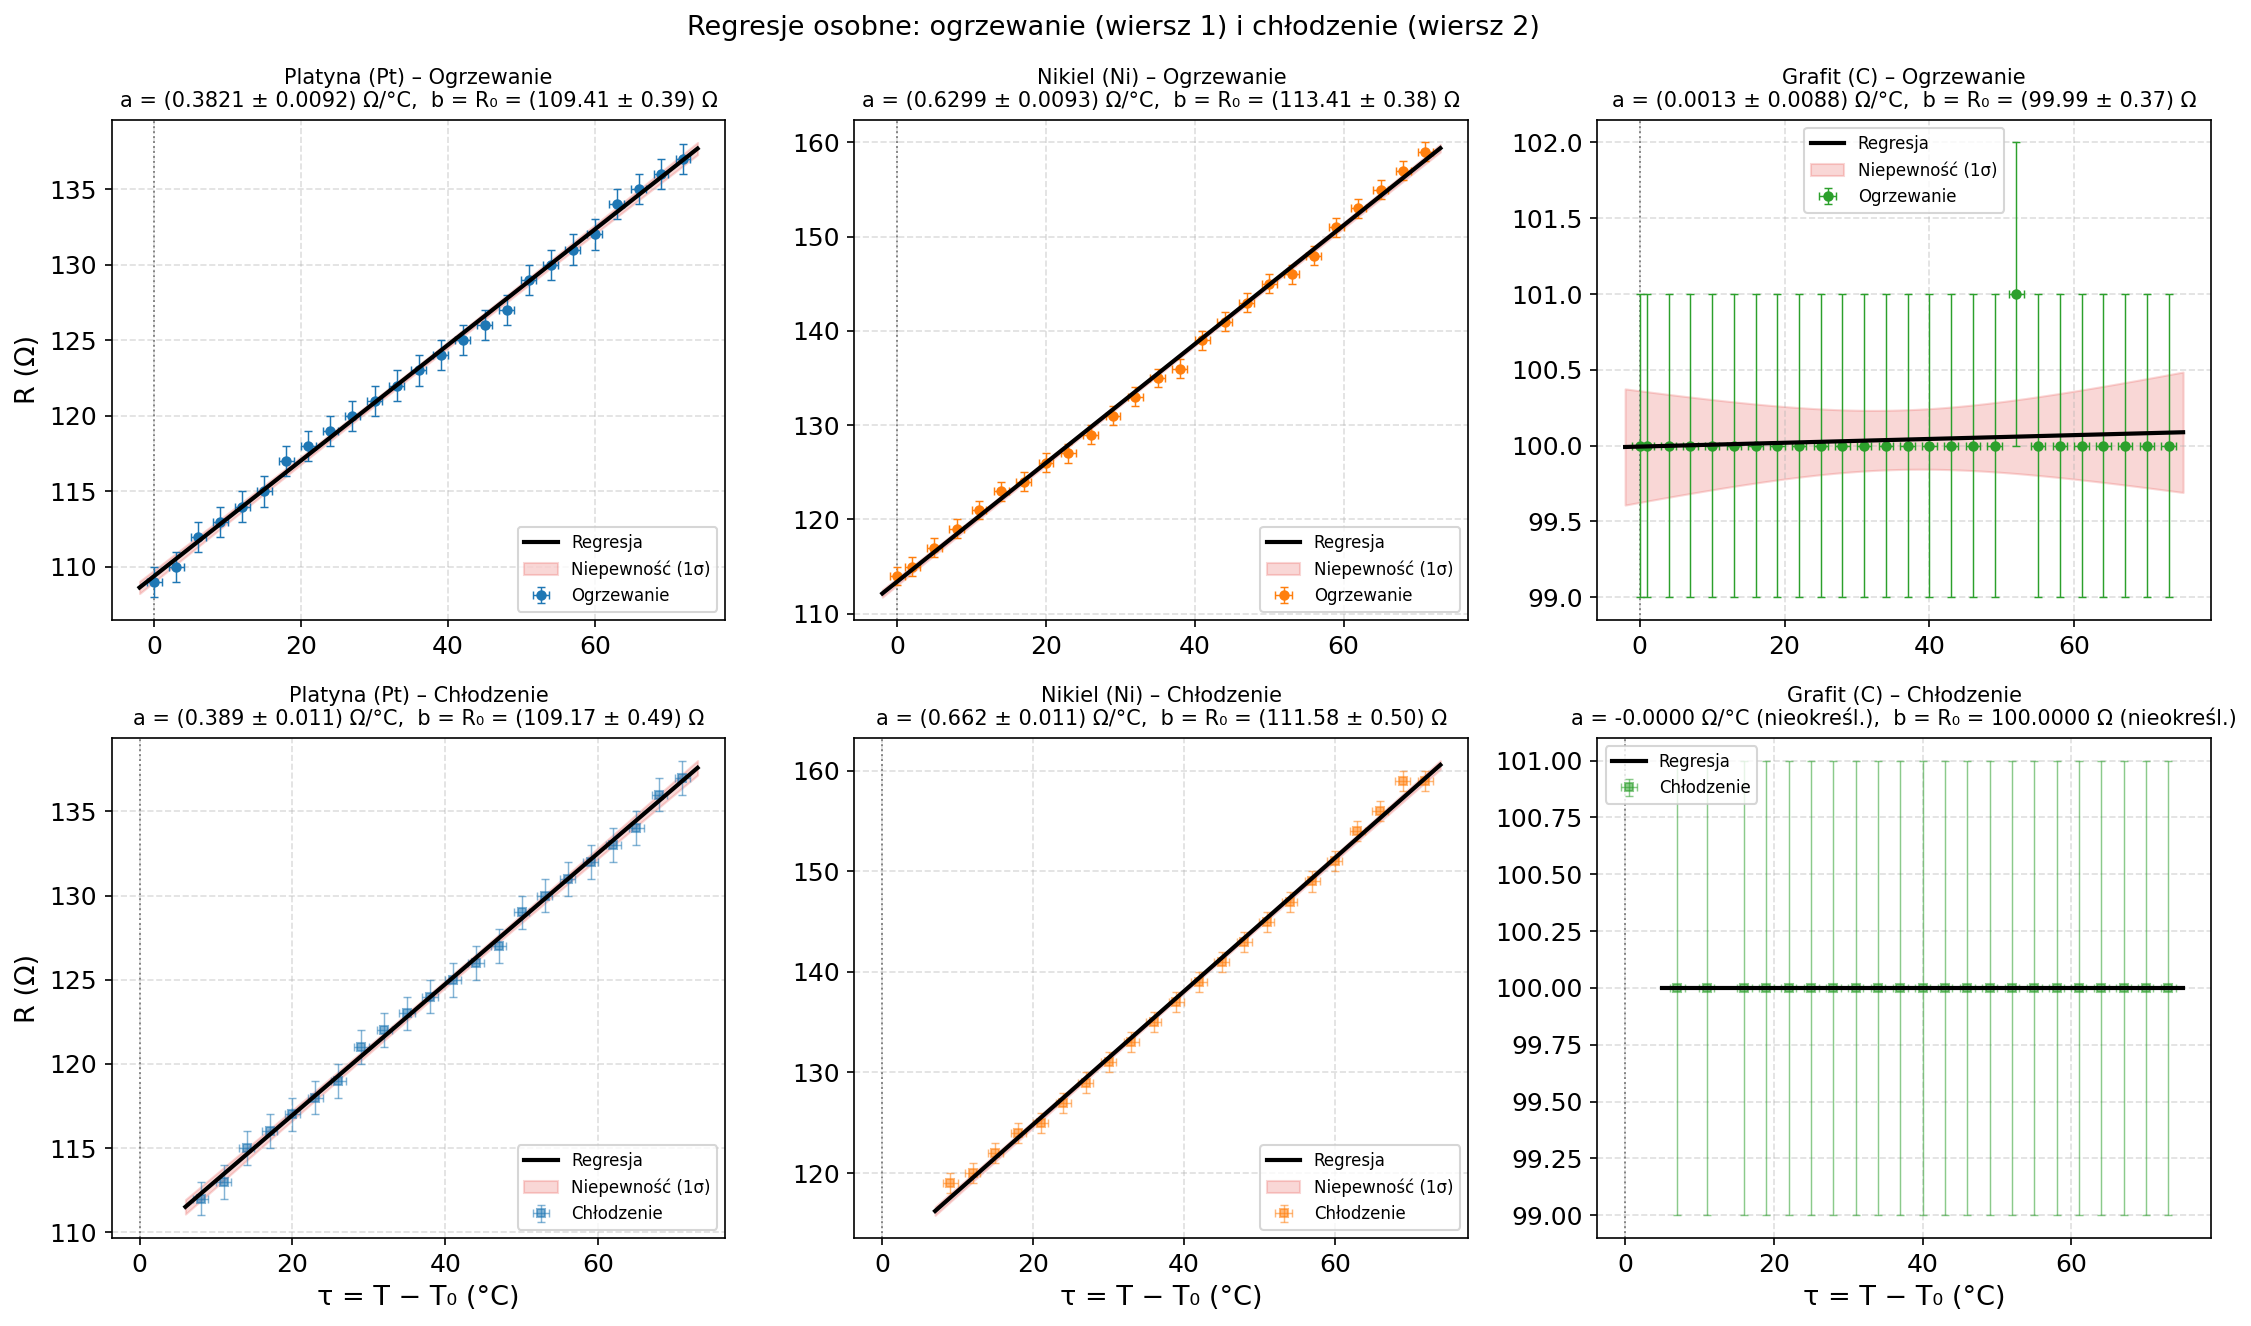

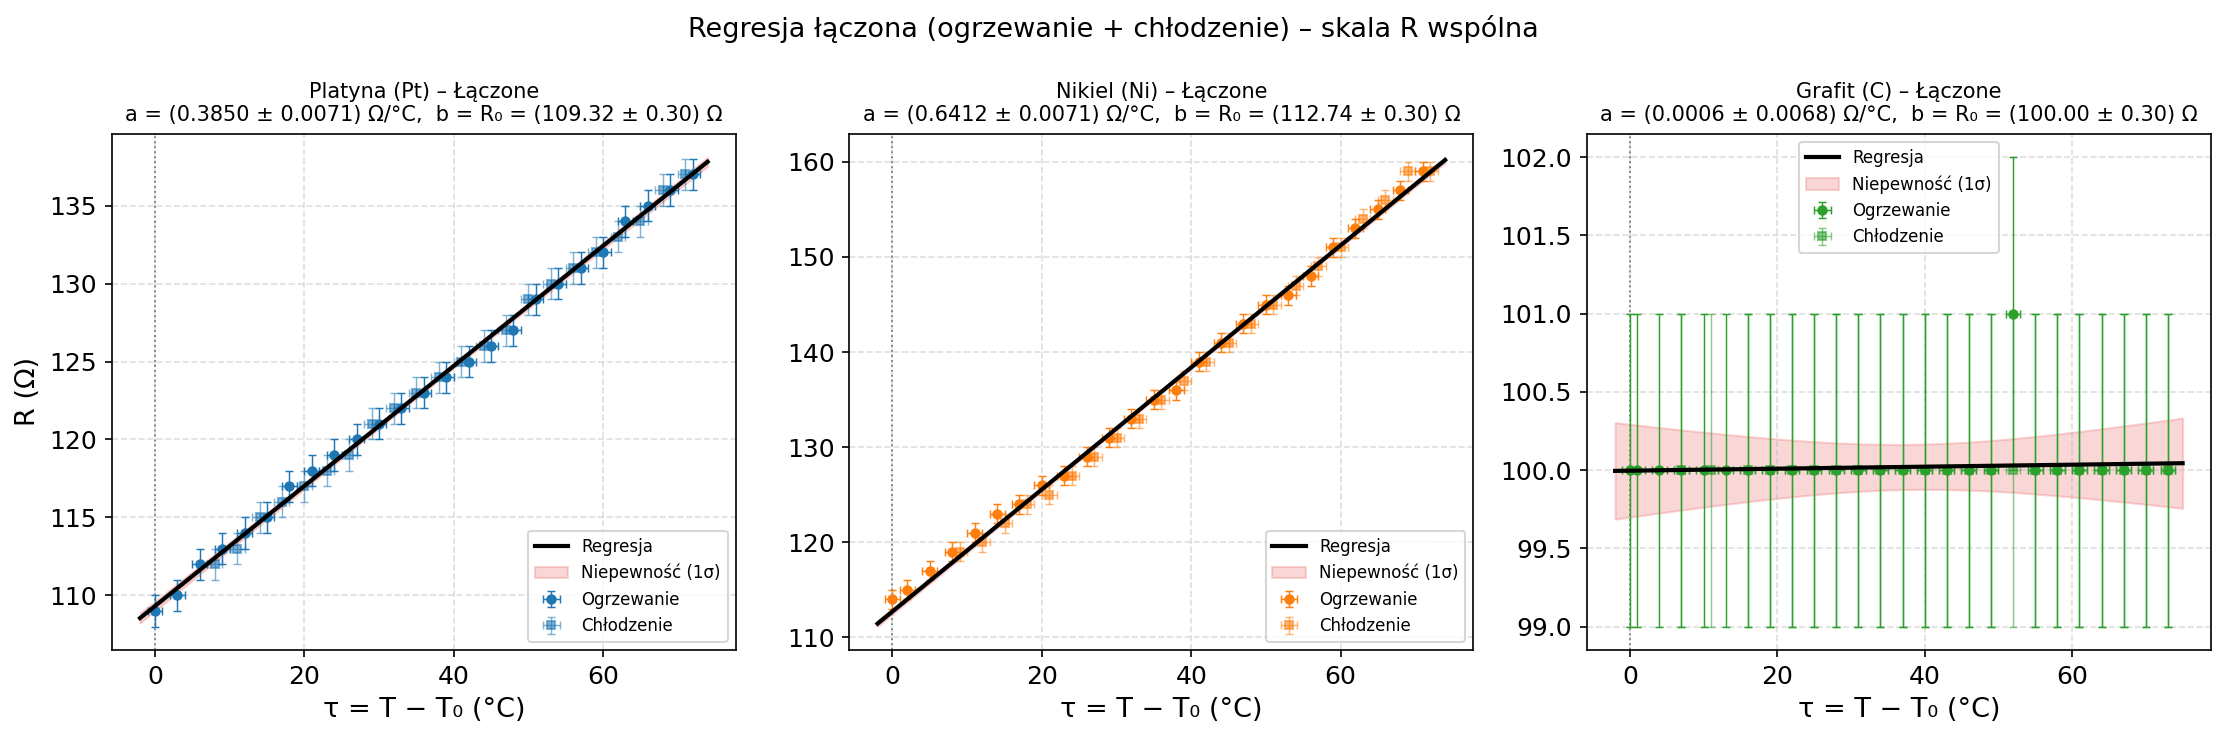

Zapisano: wykres2_regresja_osobne.pdf, wykres3_regresja_laczona.pdf


In [13]:
def plot_regression_band(ax, res, color, data_heating=None, data_cooling=None,
                          show_heating=True, show_cooling=True):
    """Rysuje punkty (oś x: τ = T − T₀) i regresję z pasmem niepewności."""
    if show_heating and data_heating is not None:
        dh = data_heating
        tau_h = dh['T'].values - T0
        ax.errorbar(tau_h, dh['R'], xerr=dh['u_T'], yerr=dh['u_R'],
                    fmt='o', color=color, markersize=4, capsize=2,
                    elinewidth=0.7, capthick=0.7, label='Ogrzewanie', zorder=5)
    if show_cooling and data_cooling is not None:
        dc = data_cooling
        tau_c = dc['T'].values - T0
        ax.errorbar(tau_c, dc['R'], xerr=dc['u_T'], yerr=dc['u_R'],
                    fmt='s', color=color, markersize=4, capsize=2,
                    elinewidth=0.7, capthick=0.7, alpha=0.55,
                    label='Chłodzenie', zorder=4)

    tau_fit = np.linspace(res['tau_all'].min() - 2, res['tau_all'].max() + 2, 400)
    R_fit   = linear_model(tau_fit, res['a'], res['b'])
    ax.plot(tau_fit, R_fit, color='black', linewidth=2.0, label='Regresja', zorder=6)

    # linia pionowa w τ=0 (T=T₀) — tu wyraz wolny = R₀
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.9)

    pcov    = res['pcov']
    var_fit = pcov[0,0]*tau_fit**2 + pcov[1,1] + 2*tau_fit*pcov[0,1]
    if np.all(np.isfinite(var_fit)) and np.all(var_fit >= 0):
        u_fit = np.sqrt(var_fit)
        ax.fill_between(tau_fit, R_fit - u_fit, R_fit + u_fit,
                        color=C_FIT, alpha=0.2, label='Niepewność (1σ)')


def reg_title(mat_label, phase_label, res):
    def fmt(val, unc, unit):
        if np.isfinite(unc):
            v, u = format_val_unc(val, unc)
            return f"({v} ± {u}) {unit}"
        else:
            return f"{val:.4f} {unit} (nieokreśl.)"
    a_str = fmt(res['a'], res['sa'], "Ω/°C")
    b_str = fmt(res['b'], res['sb'], "Ω")
    return f"{mat_label} – {phase_label}\na = {a_str},  b = R₀ = {b_str}"


# ── Wykres 2: regresje osobne, siatka 2×3 ─────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

phase_configs = [
    (results_h, 'Ogrzewanie', True,  False),
    (results_c, 'Chłodzenie', False, True),
]

for row, (res_dict, phase_label, sh, sc) in enumerate(phase_configs):
    for col, mat in enumerate(mat_list):
        ax  = axes[row, col]
        res = res_dict[mat]

        plot_regression_band(
            ax, res, MAT_COLOR[mat],
            data_heating=data[mat]['heating'],
            data_cooling=data[mat]['cooling'],
            show_heating=sh, show_cooling=sc,
        )
        ax.set_title(reg_title(materials[mat]['label'], phase_label, res),
                     fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=8)
        if row == 1:
            ax.set_xlabel('τ = T − T₀ (°C)')
        if col == 0:
            ax.set_ylabel('R (Ω)')

fig.suptitle('Regresje osobne: ogrzewanie (wiersz 1) i chłodzenie (wiersz 2)',
             fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig('wykres2_regresja_osobne.pdf', format='pdf', bbox_inches='tight')
plt.close(fig)


# ── Wykres 3: regresja łączona, siatka 1×3 ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col, mat in enumerate(mat_list):
    ax  = axes[col]
    res = results_all[mat]

    plot_regression_band(
        ax, res, MAT_COLOR[mat],
        data_heating=data[mat]['heating'],
        data_cooling=data[mat]['cooling'],
        show_heating=True, show_cooling=True,
    )
    ax.set_title(reg_title(materials[mat]['label'], 'Łączone', res),
                 fontsize=10)
    ax.set_xlabel('τ = T − T₀ (°C)')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
    if col == 0:
        ax.set_ylabel('R (Ω)')

fig.suptitle('Regresja łączona (ogrzewanie + chłodzenie) – skala R wspólna',
             fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig('wykres3_regresja_laczona.pdf', format='pdf', bbox_inches='tight')
plt.close(fig)

print('Zapisano: wykres2_regresja_osobne.pdf, wykres3_regresja_laczona.pdf')

## 5. Wyznaczone współczynniki temperaturowe α

In [ ]:
print(f"Temperatura odniesienia T₀ = {T0} °C\n")

phase_sets = [
    ('Ogrzewanie', results_h),
    ('Chłodzenie', results_c),
    ('Łączone',    results_all),
]

# ── Tabela współczynników regresji ────────────────────────────────────────────
print(f"{'Faza':<12} {'Materiał':<15} {'a [Ω/°C]':>12} {'u(a)':>9} "
      f"{'b=R₀ [Ω]':>10} {'u(R₀)':>7}")
print("─" * 75)
for phase_label, res_dict in phase_sets:
    for mat in mat_list:
        r = res_dict[mat]
        print(f"{phase_label:<12} {materials[mat]['label']:<15} "
              f"{r['a']:>12.5f} {r['sa']:>9.5f} "
              f"{r['b']:>10.3f} {r['sb']:>7.3f}")
    print()

# ── Porównanie b=R₀ z pomiarem bezpośrednim ───────────────────────────────────
R0_direct = {'Pt': 109.0, 'Ni': 113.0, 'C': 100.0}
print("\nPorównanie b=R₀ (regresja łączona) z pomiarem bezpośrednim:\n")
print(f"{'Materiał':<15} {'b=R₀ [Ω]':>10} {'u(b)':>7} {'R₀ bezp. [Ω]':>14} {'|Δ|/u':>8}")
print("─" * 60)
for mat in mat_list:
    r = results_all[mat]
    r0d = R0_direct[mat]
    diff = abs(r['b'] - r0d)
    nsig = diff / r['sb'] if np.isfinite(r['sb']) and r['sb'] > 0 else float('nan')
    print(f"{materials[mat]['label']:<15} {r['b']:>10.3f} {r['sb']:>7.3f} {r0d:>14.1f} {nsig:>7.1f}σ")

# ── Tabela α z porównaniem z literaturą ───────────────────────────────────────
print(f"\n\n{'Faza':<12} {'Materiał':<15} {'α [10⁻³/K]':>13} {'u(α)':>9} "
      f"{'α_lit':>9} {'|Δ|/u':>8}")
print("─" * 75)
for phase_label, res_dict in phase_sets:
    for mat in mat_list:
        r     = res_dict[mat]
        a_exp = r['alpha'] * 1e3
        u_a   = r['u_alpha'] * 1e3
        a_l   = alpha_lit[mat] * 1e3
        nsig  = abs(a_exp - a_l) / u_a if np.isfinite(u_a) and u_a > 0 else float('nan')
        print(f"{phase_label:<12} {materials[mat]['label']:<15} "
              f"{a_exp:>13.4f} {u_a:>9.4f} {a_l:>9.4f} {nsig:>7.1f}σ")
    print()

## 6. Wyznaczenie α z dwóch skrajnych punktów pomiarowych

Zgodnie z zaleceniami skryptu, wyznaczamy temperaturowy współczynnik oporu właściwego $\alpha$ z dwóch skrajnych pomiarów. Dla ujednolicenia wybieramy z fazy pierwszej (ogrzewanie) pierwszy pomiar (temperatura pokojowa $T_1$) i ostatni pomiar (temperatura blisko wrzenia wody $T_2$).

Zależność: $R_i = R_0 [1 + \alpha(T_i - T_0)]$, $i=1,2$.
Z tego wyliczamy $a = \frac{R_2 - R_1}{T_2 - T_1}$.
Następnie wyznaczamy opór w temperaturze odniesienia $T_0$: $R_0 = R_1 - a(T_1 - T_0)$ i na końcu współczynnik:
$$\alpha = \frac{a}{R_0}$$
Wyznaczamy też niepewności $u_a$, $u_{R_0}$ oraz $u_\alpha$ z prawa przenoszenia błędów z pełnych pochodnych.

In [15]:
def calc_2point_alpha(R1, u_R1, R2, u_R2, T1, u_T1, T2, u_T2, T0):
    a = (R2 - R1) / (T2 - T1)
    R0 = R1 - a * (T1 - T0)
    alpha = a / R0
    
    # Numeryczne wyznaczenie pochodnych (prostsze i odporne na błędy wzorów analitycznych)
    eps = 1e-6
    d_R1 = ( ( (R2 - (R1+eps))/(T2 - T1) ) / ((R1+eps) - (R2 - (R1+eps))/(T2 - T1)*(T1-T0)) - alpha ) / eps
    d_R2 = ( ( ((R2+eps) - R1)/(T2 - T1) ) / (R1 - ((R2+eps) - R1)/(T2 - T1)*(T1-T0)) - alpha ) / eps
    d_T1 = ( ( (R2 - R1)/(T2 - (T1+eps)) ) / (R1 - (R2 - R1)/(T2 - (T1+eps))*((T1+eps)-T0)) - alpha ) / eps
    d_T2 = ( ( (R2 - R1)/((T2+eps) - T1) ) / (R1 - (R2 - R1)/((T2+eps) - T1)*(T1-T0)) - alpha ) / eps
    
    u_alpha = np.sqrt( (d_R1 * u_R1)**2 + (d_R2 * u_R2)**2 + (d_T1 * u_T1)**2 + (d_T2 * u_T2)**2 )
    
    return a, R0, alpha, u_alpha

results_2pt = {}

print("Analiza dwóch skrajnych punktów (temperatura pokojowa vs. zbliżona do wrzenia):\n")
print(f"{'Materiał':<12} {'T_1 [°C]':>8} {'R_1 [Ω]':>8} {'T_2 [°C]':>8} {'R_2 [Ω]':>8} {'α [10⁻³/K]':>13} {'u(α)':>8} {'|Δ|/u':>8}")
print("-" * 85)

for mat in mat_list:
    df = data[mat]['heating']
    # Punkty: pierwszy (pokojowa) i ostatni (najgorętszy)
    pt1 = df.iloc[0]
    pt2 = df.iloc[-1]
    
    T1, u_T1, R1, u_R1 = pt1['T'], pt1['u_T'], pt1['R'], pt1['u_R']
    T2, u_T2, R2, u_R2 = pt2['T'], pt2['u_T'], pt2['R'], pt2['u_R']
    
    a, R0, num_a, num_ua = calc_2point_alpha(R1, u_R1, R2, u_R2, T1, u_T1, T2, u_T2, T0)
    
    results_2pt[mat] = {
        'T1': T1, 'R1': R1, 'T2': T2, 'R2': R2,
        'alpha': num_a, 'u_alpha': num_ua, 'a': a, 'R0': R0
    }
    
    a_exp = num_a * 1e3
    u_a   = num_ua * 1e3
    a_l   = alpha_lit[mat] * 1e3
    nsig  = abs(a_exp - a_l) / u_a
    
    print(f"{materials[mat]['label']:<12} {T1:>8.1f} {R1:>8.1f} {T2:>8.1f} {R2:>8.1f} "
          f"{a_exp:>13.4f} {u_a:>8.4f} {nsig:>7.1f}σ")

Analiza dwóch skrajnych punktów (temperatura pokojowa vs. zbliżona do wrzenia):

Materiał     T_1 [°C]  R_1 [Ω] T_2 [°C]  R_2 [Ω]    α [10⁻³/K]     u(α)    |Δ|/u
-------------------------------------------------------------------------------------
Platyna (Pt)     22.0    109.0     94.0    137.0        3.5678   0.2196     1.5σ
Nikiel (Ni)      22.0    114.0     93.0    159.0        5.5597   0.2510     1.8σ
Grafit (C)       22.0    100.0     95.0    100.0        0.0000   0.1937     2.6σ


In [16]:
print("Porównanie metod wyznaczania α (regresja łączona vs. metoda 2 punktów):\n")
print(f"{'Materiał':<15} {'α (regresja) [10⁻³/K]':>22} {'α (2 pkt) [10⁻³/K]':>21} {'Różnica':>11}")
print("-" * 75)

for mat in mat_list:
    a_reg = results_all[mat]['alpha'] * 1e3
    u_a_reg = results_all[mat]['u_alpha'] * 1e3
    
    a_2pt = results_2pt[mat]['alpha'] * 1e3
    u_a_2pt = results_2pt[mat]['u_alpha'] * 1e3
    
    diff = abs(a_reg - a_2pt)
    u_diff = np.sqrt(u_a_reg**2 + u_a_2pt**2) # Oczywiście są skorelowane ze względu na dane, ale dla wygody szacujemy sumą kwadratów
    nsig = diff / u_diff
    
    # formatowanie do wypisu
    print(f"{materials[mat]['label']:<15} "
          f"{a_reg:>9.4f} ± {u_a_reg:<8.4f} "
          f"{a_2pt:>9.4f} ± {u_a_2pt:<8.4f} "
          f"{nsig:>5.1f}σ")

Porównanie metod wyznaczania α (regresja łączona vs. metoda 2 punktów):

Materiał         α (regresja) [10⁻³/K]    α (2 pkt) [10⁻³/K]     Różnica
---------------------------------------------------------------------------
Platyna (Pt)       3.5223 ± 0.0738      3.5678 ± 0.2196     0.2σ
Nikiel (Ni)        5.6877 ± 0.0766      5.5597 ± 0.2510     0.5σ
Grafit (C)         0.0064 ± 0.0679      0.0000 ± 0.1937     0.0σ
